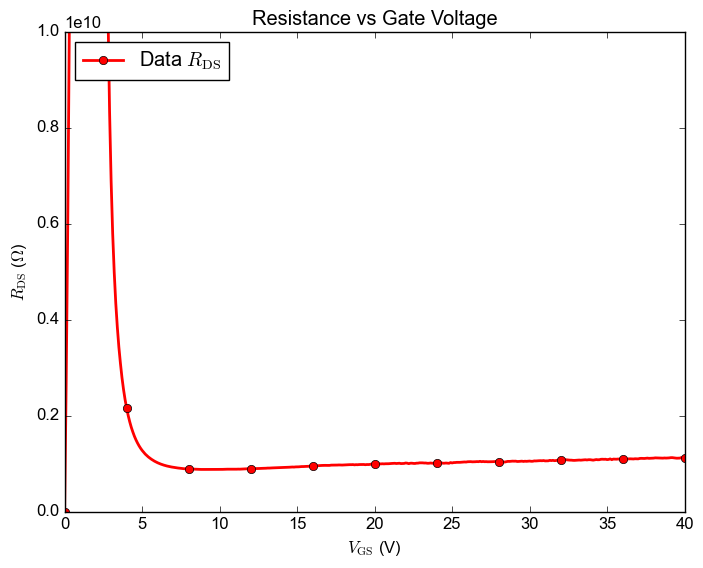

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['figure.dpi'] = 100

# IDS - VGS data
data1 = np.loadtxt("./Data-IDS-VGS/20262204001.dat")
V_GS = data1[:, 0]  # VGS values
I_DS = data1[:, 1]  # IDS values
R_DS = V_GS / I_DS  # Calculate R_DS

plt.plot(-V_GS, R_DS, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$R_\text{DS}$ ($\Omega$)")
plt.xlim(0,40)
plt.ylim(0, 1e10)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()


In [35]:
V_T = 5
def func(x, a, b):
    return a + b/ (x - V_T)

popt, pcov = curve_fit(func, -V_GS, R_DS, bounds=(5, 40))
R_fit = func(-V_GS, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_DS - R_fit) ** 2)
ss_tot = np.sum((R_DS - np.mean(R_DS)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr


print(f"a = Rc = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")


plt.plot(-V_GS, R_DS, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(-V_GS, R_fit, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$R_\text{DS}$ ($\Omega$)")
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()

C:\Users\lugwi\AppData\Local\Temp\ipykernel_28112\2273133840.py:3: RuntimeWarning: divide by zero encountered in divide
  return a + b/ (x - V_T)
c:\Users\lugwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


ValueError: Residuals are not finite in the initial point.